# APPL


## Imports


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, GRU, GlobalMaxPooling1D, GlobalAveragePooling1D, Concatenate
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional
from tensorflow.keras.layers import SpatialDropout1D, BatchNormalization, Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import GlobalMaxPooling1D
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import gc
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)

## Prepare dataset


In [ ]:
dataset = load_data('AAPL_final.csv', columns=['body_clean', 'entities'])

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train, X_val, Y_train, Y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.1,
    random_state=2,
    stratify=y_all
)

# Tokenize text to integers
tokenizer = Tokenizer(num_words=20000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# choose length for padding based on 95th percentile
train_lens = [len(s) for s in tokenizer.texts_to_sequences(X_train)]
maxlen = int(np.percentile(train_lens, 95))

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=maxlen, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=maxlen, padding='post', truncating='post')

# Keep integer labels for class-weight calculation
y_train_int = Y_train.copy()
y_val_int   = Y_val.copy()

# Convert labels to one-hot encoding
Y_train = to_categorical(y_train_int, num_classes=2)
Y_val   = to_categorical(y_val_int,   num_classes=2)

# Compute balanced class weights and then bias training a bit more toward bearish examples
classes = np.unique(y_train_int)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
class_weight = {int(c): float(w) for c, w in zip(classes, class_weights)}

## Embedder for pre-trained embeddings


In [ ]:
glove_path = 'embeddings/glove.twitter.27B.100d.txt'
vocab_size = 20000
embedding_dim = 100

embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index[word] = np.asarray(values[1:], dtype='float32')
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

## GPU configuration and building LSTM layers


In [ ]:
cuda112_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin"
cuda112_nvvp = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\libnvvp"
os.environ["PATH"] = f"{cuda112_bin};{cuda112_nvvp};" + os.environ.get("PATH", "")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print('GPUs:', tf.config.list_physical_devices('GPU'))
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

inputs = Input(shape=(maxlen,))
x = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=True, input_length=maxlen)(inputs)
x = SpatialDropout1D(0.2)(x)

# Keep LSTM CuDNN-compatible for faster GPU training.
x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
x = Bidirectional(LSTM(128, return_sequences=True))(x)

x_max = GlobalMaxPooling1D()(x)
x_avg = GlobalAveragePooling1D()(x)
x = Concatenate()([x_max, x_avg])

x = BatchNormalization()(x)
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(3e-5))(x)
x = Dropout(0.35)(x)
outputs = Dense(2, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

## Set up callbacks and model


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-6,
    ),
]

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    class_weight=class_weight,
)

test_loss, test_acc = model.evaluate(X_val, Y_val, verbose=0)
print(f'Validation Accuracy: {test_acc:.4f}')

## Calibrated metrics (second-stage threshold tuning)


In [ ]:
y_true = np.argmax(Y_val, axis=1)
y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)
print(f"Accuracy:        {acc:.4f}")
print(f"Precision macro: {p_macro:.4f} | weighted: {p_weighted:.4f}")
print(f"Recall macro:    {r_macro:.4f} | weighted: {r_weighted:.4f}")
print(f"F1 macro:        {f1_macro:.4f} | weighted: {f1_weighted:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

print('Confusion matrix:')
print(confusion_matrix(y_true, y_pred))

## Loss curve


In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
gc.collect()
tf.keras.backend.clear_session()

# AMZN


## Imports


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, GRU, GlobalMaxPooling1D, GlobalAveragePooling1D, Concatenate
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional
from tensorflow.keras.layers import SpatialDropout1D, BatchNormalization, Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import GlobalMaxPooling1D
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import gc
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)

## Prepare dataset


In [ ]:
dataset = load_data('AMZN_final.csv', columns=['body_clean', 'entities'])

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train, X_val, Y_train, Y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.1,
    random_state=2,
    stratify=y_all
)

# Tokenize text to integers
tokenizer = Tokenizer(num_words=20000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# choose length for padding based on 95th percentile
train_lens = [len(s) for s in tokenizer.texts_to_sequences(X_train)]
maxlen = int(np.percentile(train_lens, 95))

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=maxlen, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=maxlen, padding='post', truncating='post')

# Keep integer labels for class-weight calculation
y_train_int = Y_train.copy()
y_val_int   = Y_val.copy()

# Convert labels to one-hot encoding
Y_train = to_categorical(y_train_int, num_classes=2)
Y_val   = to_categorical(y_val_int,   num_classes=2)

# Compute balanced class weights and then bias training a bit more toward bearish examples
classes = np.unique(y_train_int)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
class_weight = {int(c): float(w) for c, w in zip(classes, class_weights)}

## Embedder for pre-trained embeddings


In [ ]:
glove_path = 'embeddings/glove.twitter.27B.100d.txt'
vocab_size = 20000
embedding_dim = 100

embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index[word] = np.asarray(values[1:], dtype='float32')
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

## GPU configuration and building LSTM layers


In [ ]:
cuda112_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin"
cuda112_nvvp = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\libnvvp"
os.environ["PATH"] = f"{cuda112_bin};{cuda112_nvvp};" + os.environ.get("PATH", "")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print('GPUs:', tf.config.list_physical_devices('GPU'))
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

inputs = Input(shape=(maxlen,))
x = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=True, input_length=maxlen)(inputs)
x = SpatialDropout1D(0.2)(x)

# Keep LSTM CuDNN-compatible for faster GPU training.
x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
x = Bidirectional(LSTM(128, return_sequences=True))(x)

x_max = GlobalMaxPooling1D()(x)
x_avg = GlobalAveragePooling1D()(x)
x = Concatenate()([x_max, x_avg])

x = BatchNormalization()(x)
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(3e-5))(x)
x = Dropout(0.35)(x)
outputs = Dense(2, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

## Set up callbacks and model


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-6,
    ),
]

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    class_weight=class_weight,
)

test_loss, test_acc = model.evaluate(X_val, Y_val, verbose=0)
print(f'Validation Accuracy: {test_acc:.4f}')

## Calibrated metrics (second-stage threshold tuning)


In [ ]:
y_true = np.argmax(Y_val, axis=1)
y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)
print(f"Accuracy:        {acc:.4f}")
print(f"Precision macro: {p_macro:.4f} | weighted: {p_weighted:.4f}")
print(f"Recall macro:    {r_macro:.4f} | weighted: {r_weighted:.4f}")
print(f"F1 macro:        {f1_macro:.4f} | weighted: {f1_weighted:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

print('Confusion matrix:')
print(confusion_matrix(y_true, y_pred))

## Loss curve


In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
gc.collect()
tf.keras.backend.clear_session()

# FB


## Imports


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, GRU, GlobalMaxPooling1D, GlobalAveragePooling1D, Concatenate
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional
from tensorflow.keras.layers import SpatialDropout1D, BatchNormalization, Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import GlobalMaxPooling1D
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import gc
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)

## Prepare dataset


In [2]:
dataset = load_data('FB_final.csv', columns=['body_clean', 'entities'])

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train, X_val, Y_train, Y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.1,
    random_state=2,
    stratify=y_all
)

# Tokenize text to integers
tokenizer = Tokenizer(num_words=20000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# choose length for padding based on 95th percentile
train_lens = [len(s) for s in tokenizer.texts_to_sequences(X_train)]
maxlen = int(np.percentile(train_lens, 95))

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=maxlen, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=maxlen, padding='post', truncating='post')

# Keep integer labels for class-weight calculation
y_train_int = Y_train.copy()
y_val_int   = Y_val.copy()

# Convert labels to one-hot encoding
Y_train = to_categorical(y_train_int, num_classes=2)
Y_val   = to_categorical(y_val_int,   num_classes=2)

# Compute balanced class weights and then bias training a bit more toward bearish examples
classes = np.unique(y_train_int)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
class_weight = {int(c): float(w) for c, w in zip(classes, class_weights)}

## Embedder for pre-trained embeddings


In [3]:
glove_path = 'embeddings/glove.twitter.27B.100d.txt'
vocab_size = 20000
embedding_dim = 100

embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index[word] = np.asarray(values[1:], dtype='float32')
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

## GPU configuration and building LSTM layers


In [4]:
cuda112_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin"
cuda112_nvvp = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\libnvvp"
os.environ["PATH"] = f"{cuda112_bin};{cuda112_nvvp};" + os.environ.get("PATH", "")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print('GPUs:', tf.config.list_physical_devices('GPU'))
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

inputs = Input(shape=(maxlen,))
x = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=True, input_length=maxlen)(inputs)
x = SpatialDropout1D(0.2)(x)

# Keep LSTM CuDNN-compatible for faster GPU training.
x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
x = Bidirectional(LSTM(128, return_sequences=True))(x)

x_max = GlobalMaxPooling1D()(x)
x_avg = GlobalAveragePooling1D()(x)
x = Concatenate()([x_max, x_avg])

x = BatchNormalization()(x)
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(3e-5))(x)
x = Dropout(0.35)(x)
outputs = Dense(2, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 52)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 52, 100)      2000000     ['input_1[0][0]']                
                                                                                                  
 spatial_dropout1d (SpatialDrop  (None, 52, 100)     0           ['embedding[0][0]']              
 out1D)                                                                                           
                                                                                                  
 conv1d (Conv1D)     

## Set up callbacks and model


In [5]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-6,
    ),
]

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    class_weight=class_weight,
)

test_loss, test_acc = model.evaluate(X_val, Y_val, verbose=0)
print(f'Validation Accuracy: {test_acc:.4f}')

Epoch 1/10
1139/1139 [==============================] - 21s 13ms/step - loss: 0.6304 - accuracy: 0.6571 - val_loss: 0.5187 - val_accuracy: 0.7498 - lr: 3.0000e-04
Epoch 2/10
1139/1139 [==============================] - 14s 12ms/step - loss: 0.5315 - accuracy: 0.7362 - val_loss: 0.5046 - val_accuracy: 0.7564 - lr: 3.0000e-04
Epoch 3/10
1139/1139 [==============================] - 14s 13ms/step - loss: 0.4906 - accuracy: 0.7678 - val_loss: 0.4872 - val_accuracy: 0.7699 - lr: 3.0000e-04
Epoch 4/10
1139/1139 [==============================] - 14s 13ms/step - loss: 0.4647 - accuracy: 0.7835 - val_loss: 0.4730 - val_accuracy: 0.7823 - lr: 3.0000e-04
Epoch 5/10
1139/1139 [==============================] - 14s 12ms/step - loss: 0.4439 - accuracy: 0.7966 - val_loss: 0.4781 - val_accuracy: 0.7716 - lr: 3.0000e-04
Epoch 6/10
1139/1139 [==============================] - 15s 13ms/step - loss: 0.4221 - accuracy: 0.8098 - val_loss: 0.4489 - val_accuracy: 0.7972 - lr: 1.5000e-04
Epoch 7/10
1139/1139 [

## Calibrated metrics (second-stage threshold tuning)


In [6]:
y_true = np.argmax(Y_val, axis=1)
y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)
print(f"Accuracy:        {acc:.4f}")
print(f"Precision macro: {p_macro:.4f} | weighted: {p_weighted:.4f}")
print(f"Recall macro:    {r_macro:.4f} | weighted: {r_weighted:.4f}")
print(f"F1 macro:        {f1_macro:.4f} | weighted: {f1_weighted:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

print('Confusion matrix:')
print(confusion_matrix(y_true, y_pred))

Accuracy:        0.8001
Precision macro: 0.7665 | weighted: 0.8270
Recall macro:    0.8048 | weighted: 0.8001
F1 macro:        0.7769 | weighted: 0.8067

              precision    recall  f1-score   support

           0     0.6207    0.8160    0.7051      4740
           1     0.9124    0.7935    0.8488     11447

    accuracy                         0.8001     16187
   macro avg     0.7665    0.8048    0.7769     16187
weighted avg     0.8270    0.8001    0.8067     16187

Confusion matrix:
[[3868  872]
 [2364 9083]]


## Loss curve


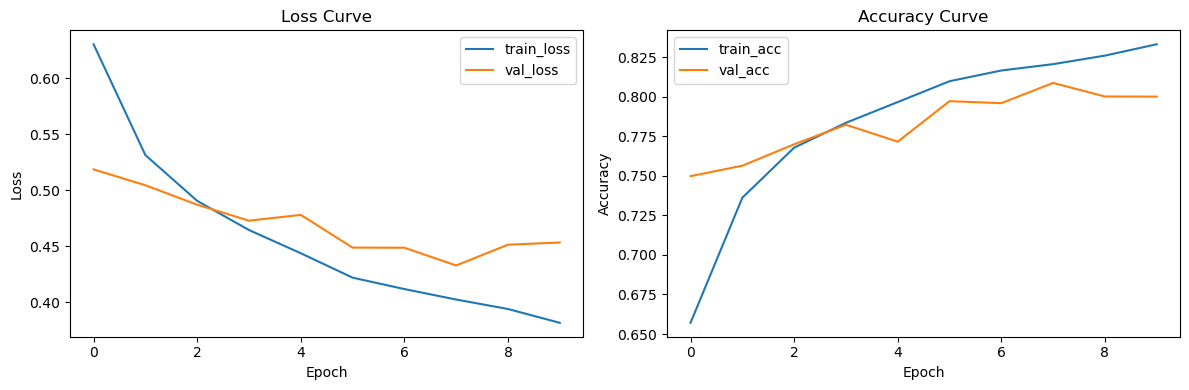

In [7]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
gc.collect()
tf.keras.backend.clear_session()

# NVDA


## Imports


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, GRU, GlobalMaxPooling1D, GlobalAveragePooling1D, Concatenate
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional
from tensorflow.keras.layers import SpatialDropout1D, BatchNormalization, Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import GlobalMaxPooling1D
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import gc
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)

## Prepare dataset


In [2]:
dataset = load_data('NVDA_final.csv', columns=['body_clean', 'entities'])

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train, X_val, Y_train, Y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.1,
    random_state=2,
    stratify=y_all
)

# Tokenize text to integers
tokenizer = Tokenizer(num_words=20000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# choose length for padding based on 95th percentile
train_lens = [len(s) for s in tokenizer.texts_to_sequences(X_train)]
maxlen = int(np.percentile(train_lens, 95))

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=maxlen, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=maxlen, padding='post', truncating='post')

# Keep integer labels for class-weight calculation
y_train_int = Y_train.copy()
y_val_int   = Y_val.copy()

# Convert labels to one-hot encoding
Y_train = to_categorical(y_train_int, num_classes=2)
Y_val   = to_categorical(y_val_int,   num_classes=2)

# Compute balanced class weights and then bias training a bit more toward bearish examples
classes = np.unique(y_train_int)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
class_weight = {int(c): float(w) for c, w in zip(classes, class_weights)}

## Embedder for pre-trained embeddings


In [3]:
glove_path = 'embeddings/glove.twitter.27B.100d.txt'
vocab_size = 20000
embedding_dim = 100

embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index[word] = np.asarray(values[1:], dtype='float32')
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

## GPU configuration and building LSTM layers


In [4]:
cuda112_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin"
cuda112_nvvp = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\libnvvp"
os.environ["PATH"] = f"{cuda112_bin};{cuda112_nvvp};" + os.environ.get("PATH", "")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print('GPUs:', tf.config.list_physical_devices('GPU'))
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

inputs = Input(shape=(maxlen,))
x = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=True, input_length=maxlen)(inputs)
x = SpatialDropout1D(0.2)(x)

# Keep LSTM CuDNN-compatible for faster GPU training.
x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
x = Bidirectional(LSTM(128, return_sequences=True))(x)

x_max = GlobalMaxPooling1D()(x)
x_avg = GlobalAveragePooling1D()(x)
x = Concatenate()([x_max, x_avg])

x = BatchNormalization()(x)
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(3e-5))(x)
x = Dropout(0.35)(x)
outputs = Dense(2, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 35)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 35, 100)      2000000     ['input_1[0][0]']                
                                                                                                  
 spatial_dropout1d (SpatialDrop  (None, 35, 100)     0           ['embedding[0][0]']              
 out1D)                                                                                           
                                                                                                  
 conv1d (Conv1D)     

## Set up callbacks and model


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
]

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    class_weight=class_weight,
)

test_loss, test_acc = model.evaluate(X_val, Y_val, verbose=0)
print(f'Validation Accuracy: {test_acc:.4f}')

Epoch 1/10
1698/1698 [==============================] - 23s 11ms/step - loss: 0.6276 - accuracy: 0.6596 - val_loss: 0.5226 - val_accuracy: 0.7682 - lr: 3.0000e-04
Epoch 2/10
1698/1698 [==============================] - 18s 10ms/step - loss: 0.5300 - accuracy: 0.7473 - val_loss: 0.4735 - val_accuracy: 0.7890 - lr: 3.0000e-04
Epoch 3/10
1698/1698 [==============================] - 17s 10ms/step - loss: 0.4923 - accuracy: 0.7761 - val_loss: 0.5103 - val_accuracy: 0.7429 - lr: 3.0000e-04
Epoch 4/10
1698/1698 [==============================] - 18s 10ms/step - loss: 0.4656 - accuracy: 0.7946 - val_loss: 0.5278 - val_accuracy: 0.7571 - lr: 1.5000e-04
Epoch 5/10
1698/1698 [==============================] - 18s 10ms/step - loss: 0.4507 - accuracy: 0.8041 - val_loss: 0.4838 - val_accuracy: 0.7819 - lr: 7.5000e-05
Validation Accuracy: 0.7890


## Calibrated metrics (second-stage threshold tuning)


In [6]:
y_true = np.argmax(Y_val, axis=1)
y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)
print(f"Accuracy:        {acc:.4f}")
print(f"Precision macro: {p_macro:.4f} | weighted: {p_weighted:.4f}")
print(f"Recall macro:    {r_macro:.4f} | weighted: {r_weighted:.4f}")
print(f"F1 macro:        {f1_macro:.4f} | weighted: {f1_weighted:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

print('Confusion matrix:')
print(confusion_matrix(y_true, y_pred))

Accuracy:        0.7890
Precision macro: 0.7034 | weighted: 0.8282
Recall macro:    0.7604 | weighted: 0.7890
F1 macro:        0.7201 | weighted: 0.8018

              precision    recall  f1-score   support

           0     0.4913    0.7116    0.5813      4969
           1     0.9155    0.8091    0.8590     19177

    accuracy                         0.7890     24146
   macro avg     0.7034    0.7604    0.7201     24146
weighted avg     0.8282    0.7890    0.8018     24146

Confusion matrix:
[[ 3536  1433]
 [ 3661 15516]]


## Loss curve


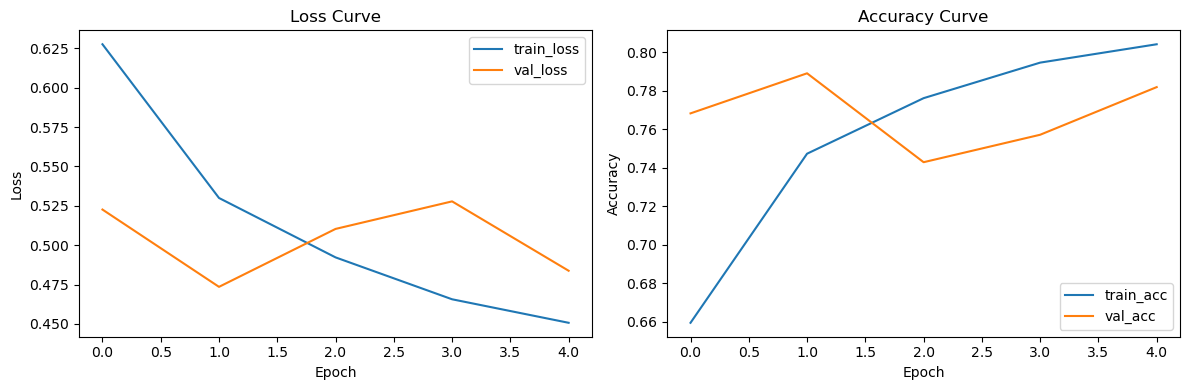

In [7]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
gc.collect()
tf.keras.backend.clear_session()

# TSLA


## Imports


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, GRU, GlobalMaxPooling1D, GlobalAveragePooling1D, Concatenate
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional
from tensorflow.keras.layers import SpatialDropout1D, BatchNormalization, Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import GlobalMaxPooling1D
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import gc
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)

## Prepare dataset


In [2]:
dataset = load_data('AMZN_final.csv', columns=['body_clean', 'entities'])

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train, X_val, Y_train, Y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.1,
    random_state=2,
    stratify=y_all
)

# Tokenize text to integers
tokenizer = Tokenizer(num_words=20000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# choose length for padding based on 95th percentile
train_lens = [len(s) for s in tokenizer.texts_to_sequences(X_train)]
maxlen = int(np.percentile(train_lens, 95))

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=maxlen, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=maxlen, padding='post', truncating='post')

# Keep integer labels for class-weight calculation
y_train_int = Y_train.copy()
y_val_int   = Y_val.copy()

# Convert labels to one-hot encoding
Y_train = to_categorical(y_train_int, num_classes=2)
Y_val   = to_categorical(y_val_int,   num_classes=2)

# Compute balanced class weights and then bias training a bit more toward bearish examples
classes = np.unique(y_train_int)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
class_weight = {int(c): float(w) for c, w in zip(classes, class_weights)}

## Embedder for pre-trained embeddings


In [3]:
glove_path = 'embeddings/glove.twitter.27B.100d.txt'
vocab_size = 20000
embedding_dim = 100

embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index[word] = np.asarray(values[1:], dtype='float32')
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

## GPU configuration and building LSTM layers


In [4]:
cuda112_bin = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin"
cuda112_nvvp = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\libnvvp"
os.environ["PATH"] = f"{cuda112_bin};{cuda112_nvvp};" + os.environ.get("PATH", "")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print('GPUs:', tf.config.list_physical_devices('GPU'))
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

inputs = Input(shape=(maxlen,))
x = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=True, input_length=maxlen)(inputs)
x = SpatialDropout1D(0.2)(x)

# Keep LSTM CuDNN-compatible for faster GPU training.
x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
x = Bidirectional(LSTM(128, return_sequences=True))(x)

x_max = GlobalMaxPooling1D()(x)
x_avg = GlobalAveragePooling1D()(x)
x = Concatenate()([x_max, x_avg])

x = BatchNormalization()(x)
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(3e-5))(x)
x = Dropout(0.35)(x)
outputs = Dense(2, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 57)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 57, 100)      2000000     ['input_1[0][0]']                
                                                                                                  
 spatial_dropout1d (SpatialDrop  (None, 57, 100)     0           ['embedding[0][0]']              
 out1D)                                                                                           
                                                                                                  
 conv1d (Conv1D)     

## Set up callbacks and model


In [5]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-6,
    ),
]

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    class_weight=class_weight,
)

test_loss, test_acc = model.evaluate(X_val, Y_val, verbose=0)
print(f'Validation Accuracy: {test_acc:.4f}')

Epoch 1/10
1663/1663 [==============================] - 27s 13ms/step - loss: 0.6317 - accuracy: 0.6491 - val_loss: 0.6835 - val_accuracy: 0.5707 - lr: 3.0000e-04
Epoch 2/10
1663/1663 [==============================] - 22s 13ms/step - loss: 0.5292 - accuracy: 0.7314 - val_loss: 0.5566 - val_accuracy: 0.7054 - lr: 3.0000e-04
Epoch 3/10
1663/1663 [==============================] - 21s 13ms/step - loss: 0.4899 - accuracy: 0.7638 - val_loss: 0.5249 - val_accuracy: 0.7381 - lr: 3.0000e-04
Epoch 4/10
1663/1663 [==============================] - 22s 13ms/step - loss: 0.4664 - accuracy: 0.7787 - val_loss: 0.5090 - val_accuracy: 0.7453 - lr: 3.0000e-04
Epoch 5/10
1663/1663 [==============================] - 22s 13ms/step - loss: 0.4460 - accuracy: 0.7903 - val_loss: 0.5457 - val_accuracy: 0.7257 - lr: 3.0000e-04
Epoch 6/10
1663/1663 [==============================] - 21s 13ms/step - loss: 0.4239 - accuracy: 0.8044 - val_loss: 0.4412 - val_accuracy: 0.7941 - lr: 1.5000e-04
Epoch 7/10
1663/1663 [

## Calibrated metrics (second-stage threshold tuning)


In [6]:
y_true = np.argmax(Y_val, axis=1)
y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)
print(f"Accuracy:        {acc:.4f}")
print(f"Precision macro: {p_macro:.4f} | weighted: {p_weighted:.4f}")
print(f"Recall macro:    {r_macro:.4f} | weighted: {r_weighted:.4f}")
print(f"F1 macro:        {f1_macro:.4f} | weighted: {f1_weighted:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

print('Confusion matrix:')
print(confusion_matrix(y_true, y_pred))

Accuracy:        0.7941
Precision macro: 0.7158 | weighted: 0.8447
Recall macro:    0.7890 | weighted: 0.7941
F1 macro:        0.7341 | weighted: 0.8088

              precision    recall  f1-score   support

           0     0.4977    0.7803    0.6077      4834
           1     0.9339    0.7977    0.8604     18815

    accuracy                         0.7941     23649
   macro avg     0.7158    0.7890    0.7341     23649
weighted avg     0.8447    0.7941    0.8088     23649

Confusion matrix:
[[ 3772  1062]
 [ 3807 15008]]


## Loss curve


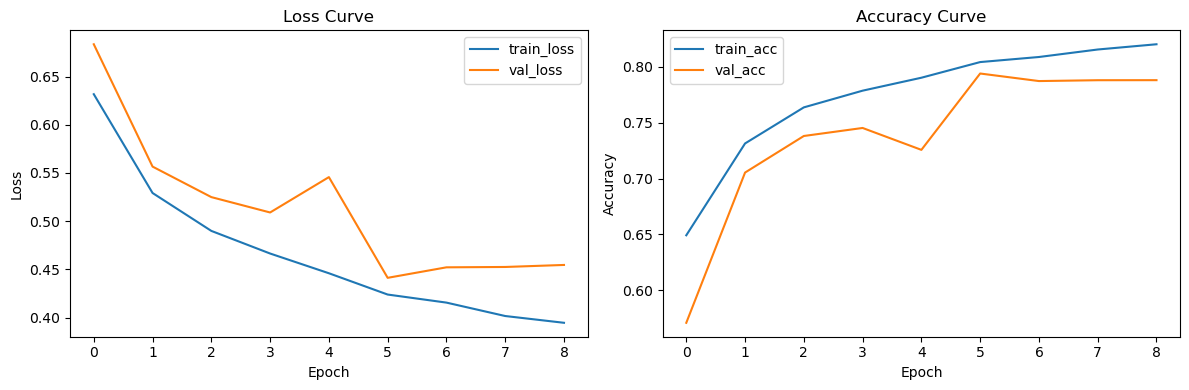

In [7]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
gc.collect()
tf.keras.backend.clear_session()